# Notebook OBjectives

 - Handle Data that is across different experiments (numbers of latents)
 - Nominally these are:
    - PLotting of loss as a function of latent dimension
    - Creating super trajectories for making movies of reconstruction

In [1]:
import json, os, jax, glob
import jax.numpy as jnp
import mdtraj as md
import matplotlib.pyplot as plt
from pyscripts.analysis import NN_Experiment_Analyzer
import pyscripts.jax_amber3 as jaa

jax:    0.4.28
jaxlib: 0.4.28
numpy:  1.26.4
python: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]
jax.devices (1 total, 1 local): [cuda(id=0)]
process_count: 1
platform: uname_result(system='Linux', node='genuinelyjollyjackalope', release='6.5.0-35-generic', version='#35~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue May  7 09:00:52 UTC 2', machine='x86_64')


$ nvidia-smi
Wed May 15 22:34:08 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.129.03             Driver Version: 535.129.03   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|==========================

In [2]:
def atom_rmsd(a, b, potential_coefficient=None): # for arrays of (n_conf, n_atom*3)
    mn = a.shape[-1]//3
    x_inds, y_inds, z_inds = jnp.arange(0,mn), jnp.arange(mn, 2*mn), jnp.arange(2*mn, 3*mn)
    return jnp.sqrt(jnp.mean((b[x_inds] - a[x_inds])**2 + (b[y_inds] - a[y_inds])**2 + (b[z_inds] - a[z_inds])**2))

gas_fun, _ = jaa.get_amber_functions('Simulation/ala_deca_peptide.prmtop')
def scaled_pot_enr_diff(a, b, potential_coefficient=None): # WITH A AS BATCH AND B AS RECON
    return ((gas_fun(a) - gas_fun(b))/gas_fun(a))**2 #Unitless quantity

class NN_Multi_Analyzer():
    def __init__(self, json_params_series:[dict], netcdf_fns:[str], checkpoint_dirs:[str]):
        assert len(json_fns) == len(netcdf_fns)
        assert len(json_fns) == len(checkpoint_dirs)

        self.experiments = {}

        for i in range(len(netcdf_fns)):
            exp = NN_Experiment_Analyzer(json_params_series[i], netcdf_fns[i], checkpoint_dirs[i])
            key = f"{exp.n_latents} Latents"
            self.experiments[key] = exp

    def super_traj_construct(self, rng_seed, n_frames=500, mode='Decoded', num_components=None):
        """
        Creates two trajectories, which can be simultaneously visualized to see reconstruction with different numbers of latents

        Parameters:
            n_frames: The number of frames from each set to use, will be a slice of every x frames of the test data such that there are n_frames
                      i.e. if test_data is size 2000, and 500 frames are requested, every fourth frame of the test set will be shown
            mode: string in ['Decoded', 'Modeled'] : If Decoded, the super traj will contain frames that were encoded and decoded by the NN
                                                     If Modeled, the super traj will contain frames generated by GMM
            num_components: if not None, must be a list of integers the same length as the number of experiments
                            Will generate samples from the Gaussian Mixture Model to compare to
        """
        assert mode in ['Decoded', 'Modeled']
        #Since all experiments should have the same numbers of dimensions in this analysis, the atomistic size will be obtained from only one
        #size_test_set = pass
        num_experiments = len(self.experiments)
        if mode == 'Modeled':
            assert num_components is not None
            assert type(num_components) == list
            assert len(num_components) == num_experiments
            assert False not in [type(num) == int for num in num_components]
        num_test_set, num_dimensions = list(self.experiments.values())[0].test_data.shape
        #print(num_test_set, num_dimensions)
        assert num_test_set % n_frames == 0
        super_traj_test = jnp.zeros((n_frames*num_experiments, num_dimensions))
        super_traj_comp = jnp.zeros((n_frames*num_experiments, num_dimensions))

        for i in range(num_experiments):
            indices = jnp.arange(0, num_test_set, num_test_set//n_frames)
            #print(indices.shape)
            #print(indices)
            test_data = list(self.experiments.values())[i].test_data
            super_traj_test = super_traj_test.at[i*n_frames:(i+1)*n_frames, :].set(test_data[indices, :])

            if mode == 'Decoded':
                comp_data, _ = list(self.experiments.values())[i].operate(rng_seed)
            elif mode == 'Modeled':
                _, comp_data = list(self.experiments.values())[i].gaussian_mm_fit(rng_seed, num_components[i])

            super_traj_comp = super_traj_comp.at[i*n_frames:(i+1)*n_frames, :].set(comp_data[indices, :])

        assert not jnp.any(super_traj_comp == 0.0) and not jnp.any(super_traj_test == 0.0)
        return super_traj_test, super_traj_comp

    def rmsd_violin_plot(self, rng_seed, title):
        #Assemble the Data
        latents, rmsds = [], []
        for key, exp in self.experiments.items():
            latents.append(exp.n_latents)
            recon, _ = exp.operate(rng_seed)
            rmsds.append(jax.vmap(atom_rmsd)(exp.test_data, recon))
        latents, rmsds = jnp.array(latents), jnp.array(rmsds)
        pos = jnp.log(latents) / jnp.log(2)
        #Make the Violin PLot
        plt.clf()
        parts = plt.violinplot(rmsds*10, pos, showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        plt.title(title)
        plt.ylabel('RMSD (Angstrom)')
        plt.xlabel('Num Latents (log base 2)')
        plt.show()

    def potential_violin_plot(self, rng_seed, title):
        #Assemble the Data
        latents, pots = [], []
        for key, exp in self.experiments.items():
            latents.append(exp.n_latents)
            recon, _ = exp.operate(rng_seed)
            pots.append(jax.jit(scaled_pot_enr_diff)(exp.test_data, recon))
        latents, pots = jnp.array(latents), jnp.array(pots)
        pos = jnp.log(latents) / jnp.log(2)
        #Make the Violin PLot
        plt.clf()
        parts = plt.violinplot(jnp.sqrt(pots), pos, showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        plt.title(title)
        plt.ylabel('Potential Deviation (%)')
        plt.yscale('log')
        plt.xlabel('Num Latents (log base 2)')
        plt.show()
            
        

2024-05-15 22:34:08.758588: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.4.131). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [3]:
rpt = 3

json_wildcard = f'bridges2_runs/5_15_24/jsons/DA_AE_Dropout_RMSD_and_Scale_*{rpt}.json'
json_fns = sorted(glob.glob(json_wildcard))

nc_wildcard = f'bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/*_latents/rpt_{rpt}/*checkpoint.nc'
netcdf_fns = sorted(glob.glob(nc_wildcard))

ckpt_wildcard = f'bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/*_latents/rpt_{rpt}/checkpoint_managed/*/default/'
all_checkpoint_dirs = sorted(glob.glob(ckpt_wildcard))
checkpoint_dirs = []
#Two checkpoints per model, always take the latest one
indices = range(1, len(all_checkpoint_dirs)+1, 2)
for ind in indices:
    checkpoint_dirs.append(all_checkpoint_dirs[ind])

assert len(json_fns) == len(netcdf_fns)
assert len(json_fns) == len(checkpoint_dirs)

In [4]:
for i in range(len(json_fns)):
    print(json_fns[i])
    print(netcdf_fns[i])
    print(checkpoint_dirs[i])
    print('#########################################################')

bridges2_runs/5_15_24/jsons/DA_AE_Dropout_RMSD_and_Scale_0001_3.json
bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/0001_latents/rpt_3/model_DA_AE_Dropout_RMSD_and_Scale_0001_checkpoint.nc
bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/0001_latents/rpt_3/checkpoint_managed/2000/default/
#########################################################
bridges2_runs/5_15_24/jsons/DA_AE_Dropout_RMSD_and_Scale_0002_3.json
bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/0002_latents/rpt_3/model_DA_AE_Dropout_RMSD_and_Scale_0002_checkpoint.nc
bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/0002_latents/rpt_3/checkpoint_managed/2400/default/
#########################################################
bridges2_runs/5_15_24/jsons/DA_AE_Dropout_RMSD_and_Scale_0004_3.json
bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/0004_latents/rpt_3/model_DA_AE_Dropout_RMSD_and_Scale_0004_checkpoint.nc
bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/0004_latents/rpt_3/checkpoint_managed/6800/defau

In [5]:
json_params_series = []
for json_fn in json_fns:
    #Json files were on Bridges2, doctor for this analysis
    with open(json_fn, 'r') as f:
        json_params = json.load(f)
    #print(json_params)
    #the json is from bridges, change file paths to be from jetstream
    #/ocean/projects/mcb160011p/josephdb/githubs/Deep-MMS/ -> /media/volume/sdb/githubs/Deep-MMS/
    for key in ["fname_dcd", "fname_prmtop", "save_dir"]:
        json_params[key] = json_params[key].replace("/ocean/projects/mcb160011p/josephdb/",
                                                    "/media/volume/Joseph-Large/")
        #print(os.path.isfile(json_params[key]))
    #print(json_params)
    json_params_series.append(json_params)

In [6]:
self = NN_Multi_Analyzer(json_params_series, netcdf_fns, checkpoint_dirs)

Load Files
{'fname_dcd': '/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/decaalanine_1us_split7.dcd', 'fname_prmtop': '/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/ala_deca_peptide.prmtop', 'fname_pdb': 'None', 'save_dir': '/media/volume/Joseph-Large/githubs/Deep-MMS/', 'data_dir': 'None', 'max_epoch': 100000, 'latent_dim': 1, 'test_slice': 3, 'data_slice_start': 0, 'data_slice_end': 'None', 'model_name': 'DA_AE_Dropout_RMSD_and_Scale', 'batch_size': 2000, 'learning_rate': 1e-06, 'dropout_rates': [0.1, 0.1, 0.1], 'potential_threshold': 10, 'model_type': 'AE', 'coordinate_scheme': 'Cartesian', 'resume_latest': False, 'report_potential': True, 'checkpoint_interval': 200}
Load Data with MDTraj
Batch data
(8000, 306) (2000, 306)
Model Init
Batch Data
Read NetCDF and Checkpoint
Load Files
{'fname_dcd': '/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/decaalanine_1us_split7.dcd', 'fname_prmtop': '/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/ala_deca_peptide

1 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x7d1bbf0f0b00>


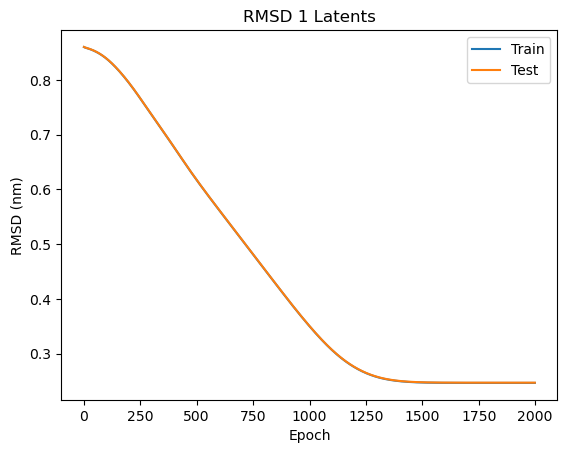

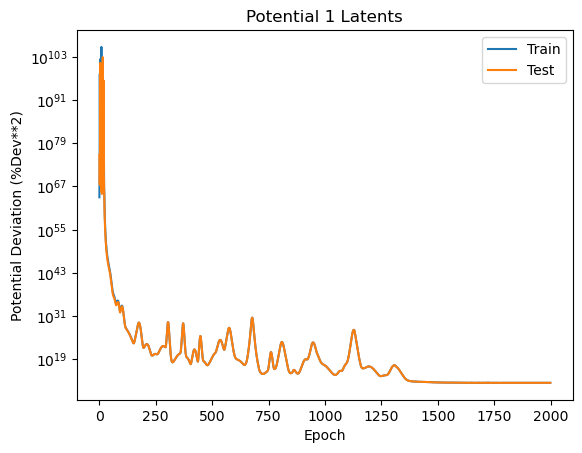

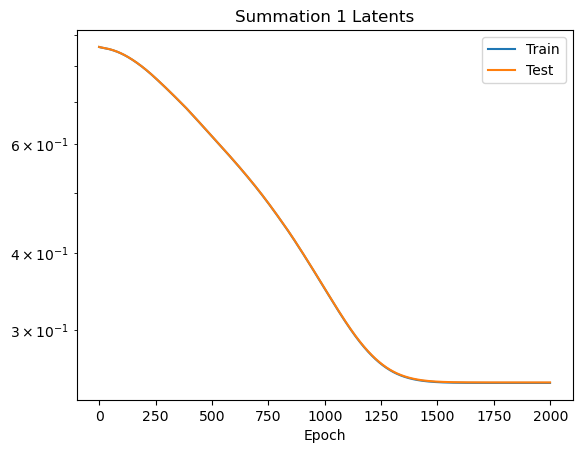

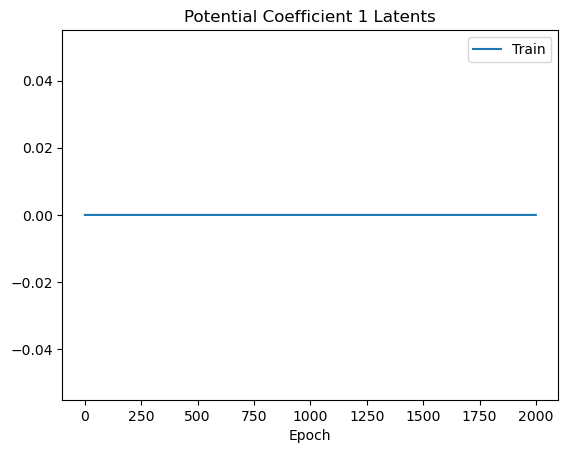

Num Epochs 2000
Last RMSD (nm): Train: 0.24670962989330292 Test 0.24715536832809448
Last PotDiff (% Deviation): Train: 2972834365112.085 Test 2967185389667.9204
2 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x7d1dbc6664b0>


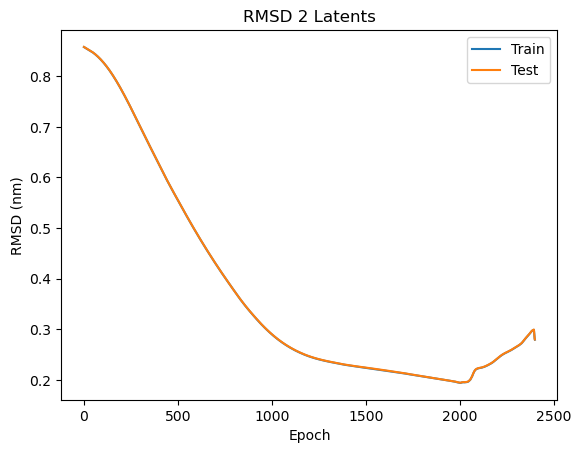

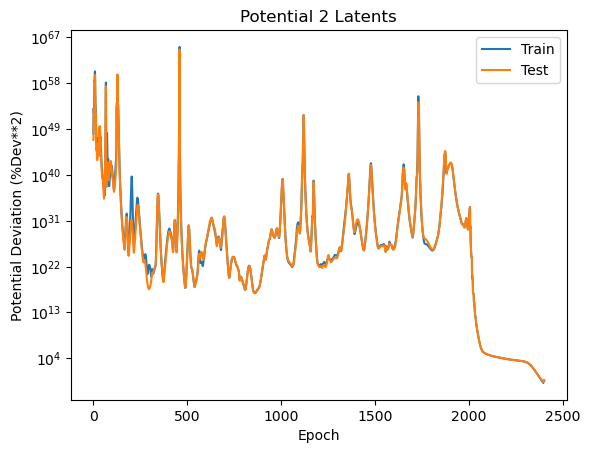

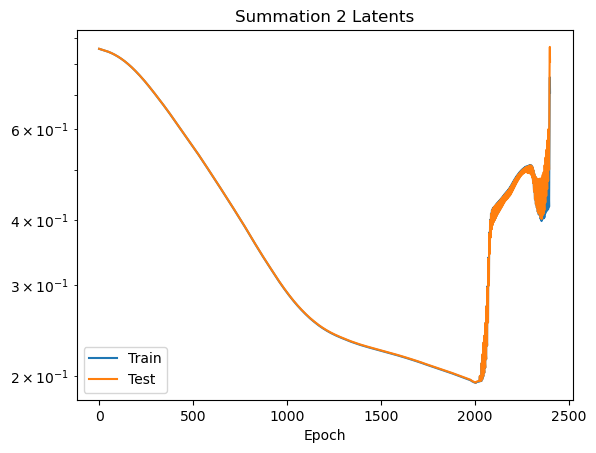

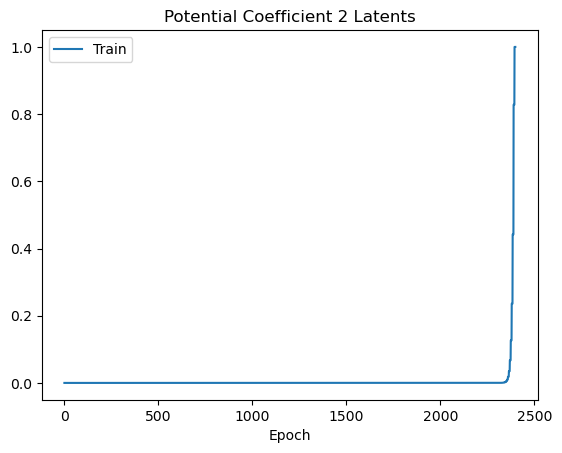

Num Epochs 2400
Last RMSD (nm): Train: 0.2794894278049469 Test 0.27986353635787964
Last PotDiff (% Deviation): Train: 0.4269370587860093 Test 0.5303853383216113
4 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x7d1bbf4a8500>


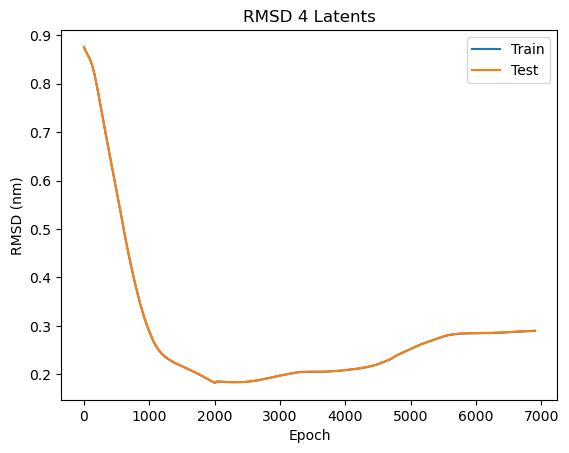

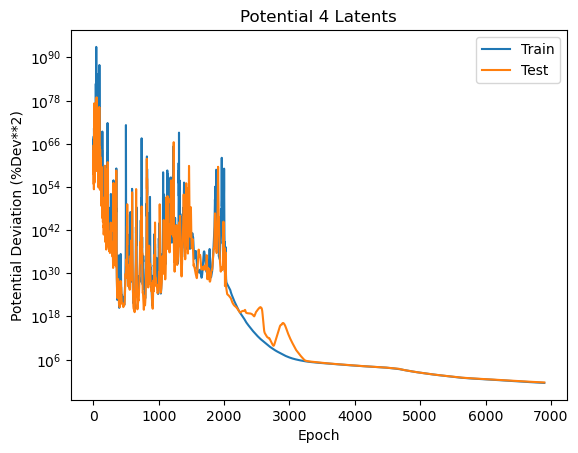

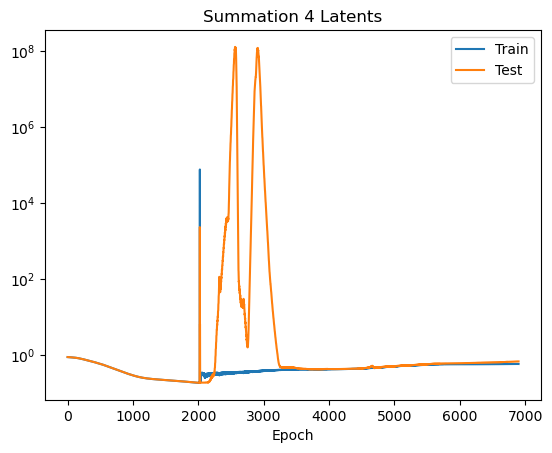

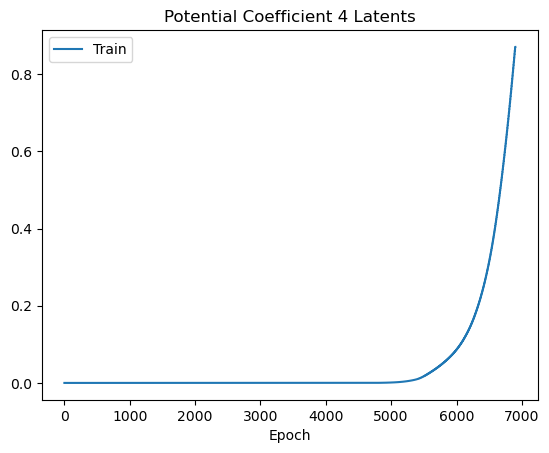

Num Epochs 6900
Last RMSD (nm): Train: 0.28987571597099304 Test 0.2903106212615967
Last PotDiff (% Deviation): Train: 0.32804661628917875 Test 0.4387158688658191
8 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x7d1b9b347650>


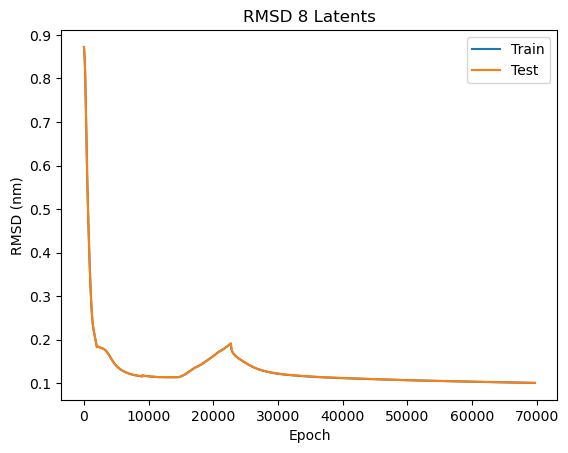

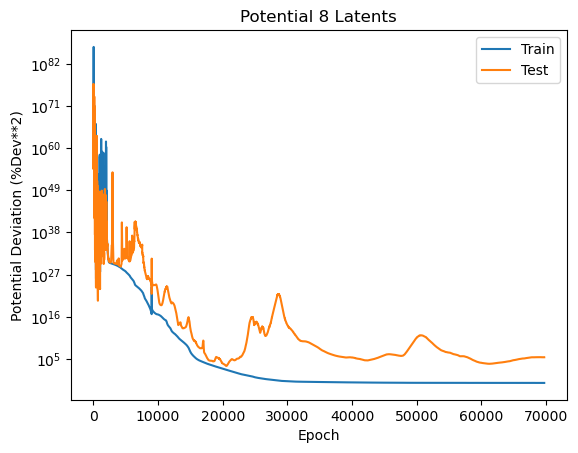

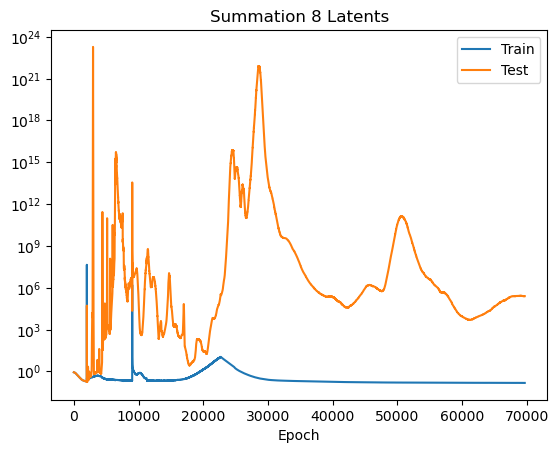

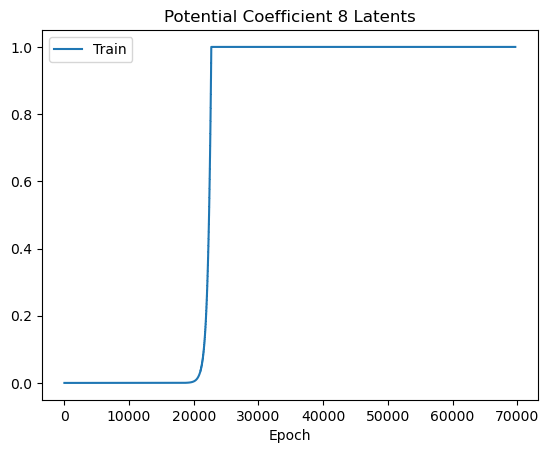

Num Epochs 69700
Last RMSD (nm): Train: 0.1004924476146698 Test 0.10060017555952072
Last PotDiff (% Deviation): Train: 0.050155598929693006 Test 251269.89297739413
16 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x7d1c304cde80>


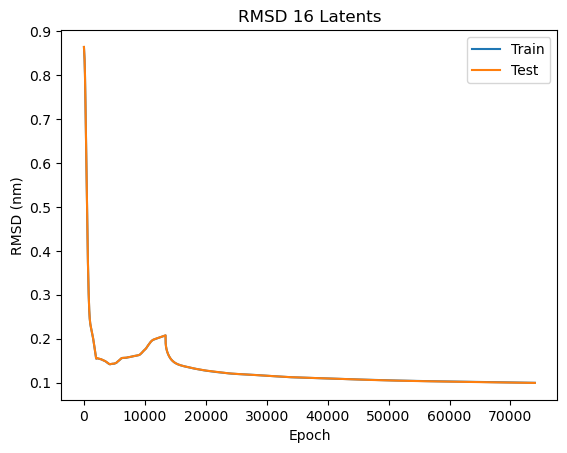

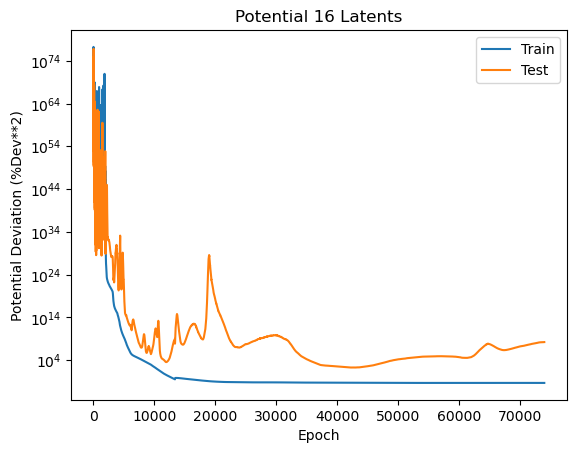

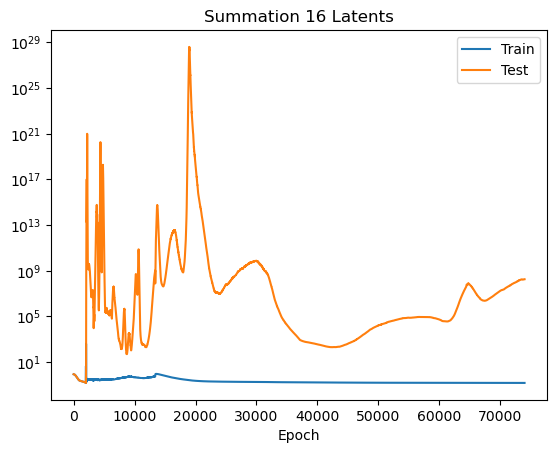

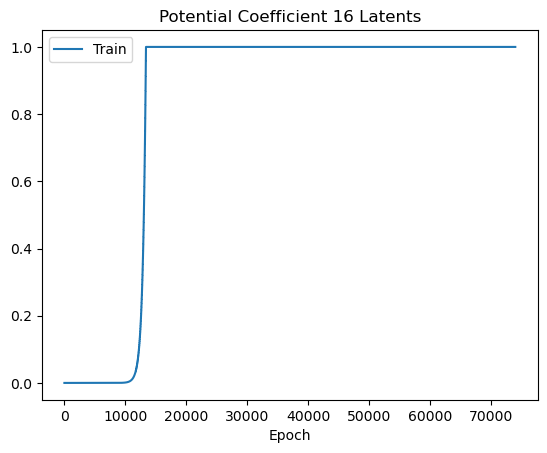

Num Epochs 74000
Last RMSD (nm): Train: 0.09955627471208572 Test 0.09929527342319489
Last PotDiff (% Deviation): Train: 0.050912051879476894 Test 178804821.93083072
32 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x7d1b74397bc0>


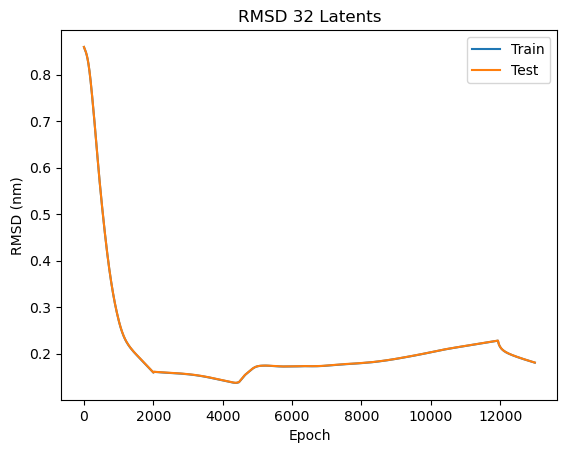

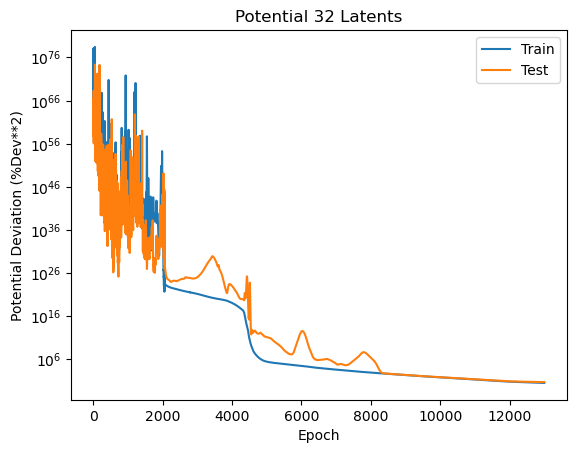

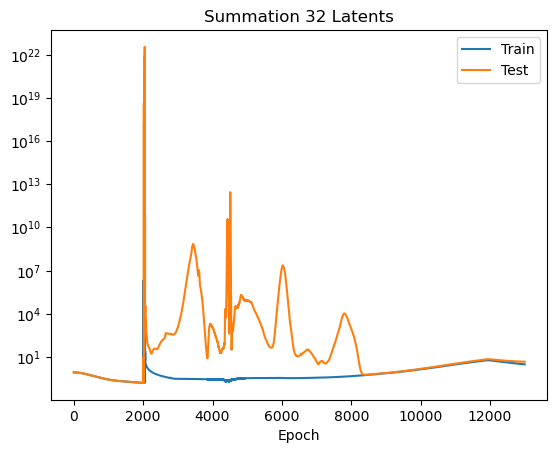

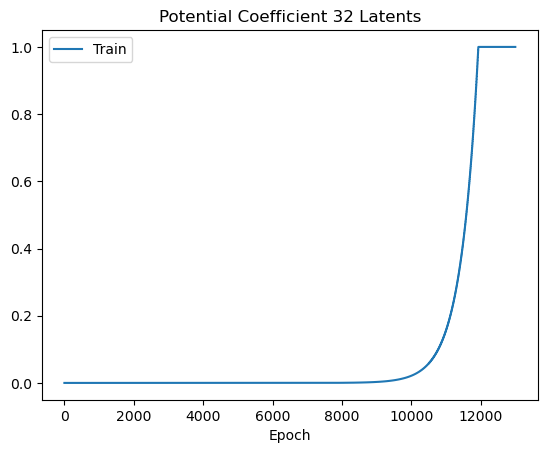

Num Epochs 13000
Last RMSD (nm): Train: 0.18081670999526978 Test 0.18098510801792145
Last PotDiff (% Deviation): Train: 2.9114013134413086 Test 4.578564162319064
64 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x7d1bbf4abfe0>


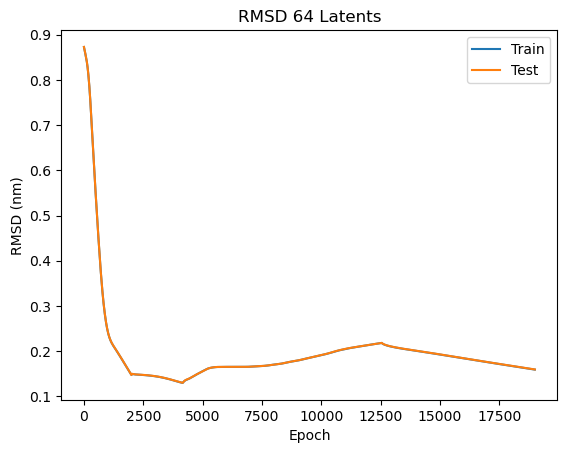

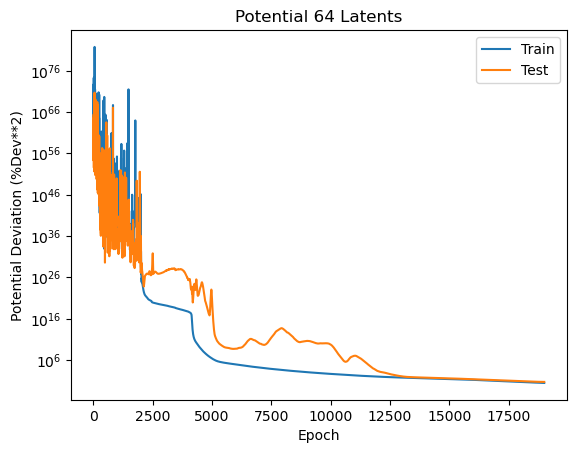

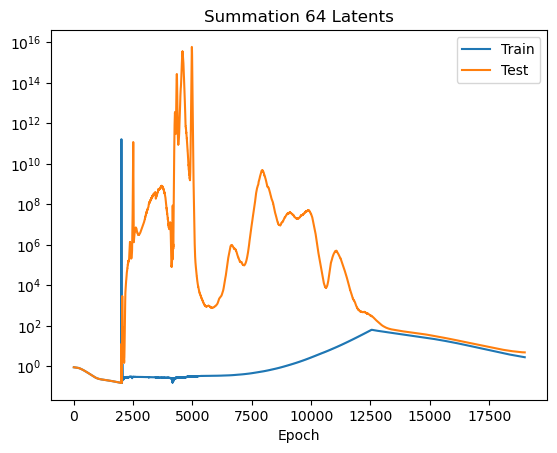

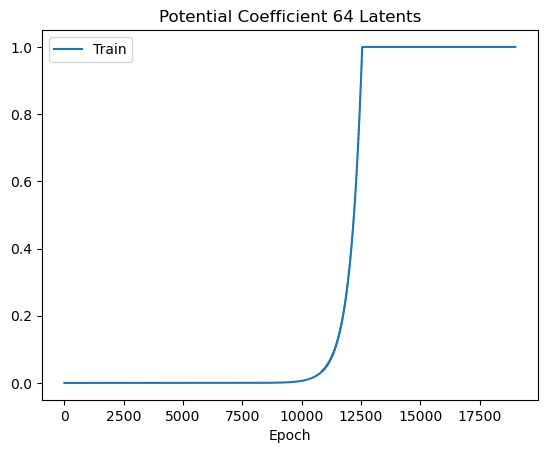

Num Epochs 19000
Last RMSD (nm): Train: 0.1592709720134735 Test 0.15960383415222168
Last PotDiff (% Deviation): Train: 2.573819022468138 Test 4.585624519406872
128 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x7d1bbf4b3d70>


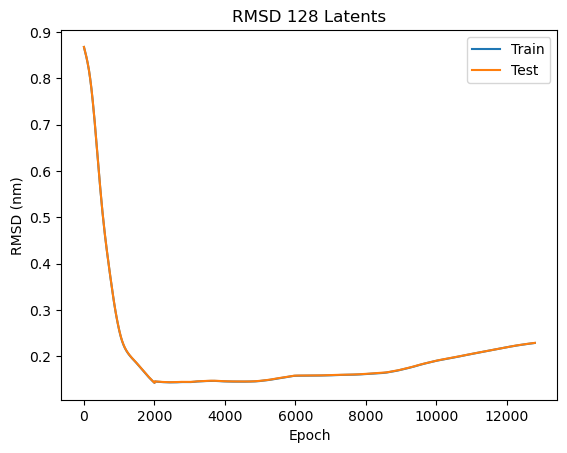

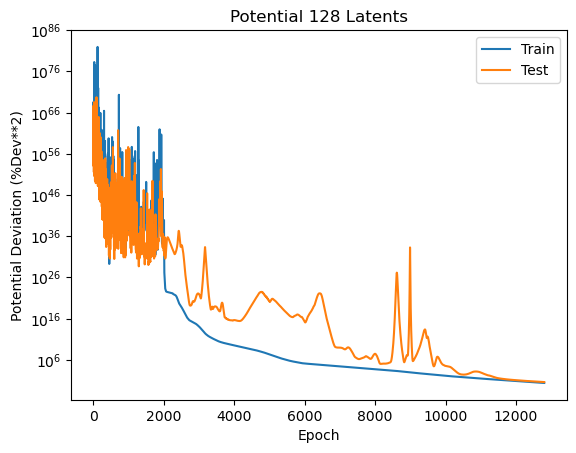

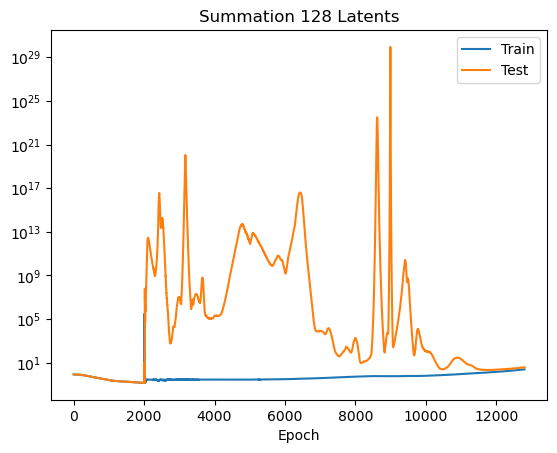

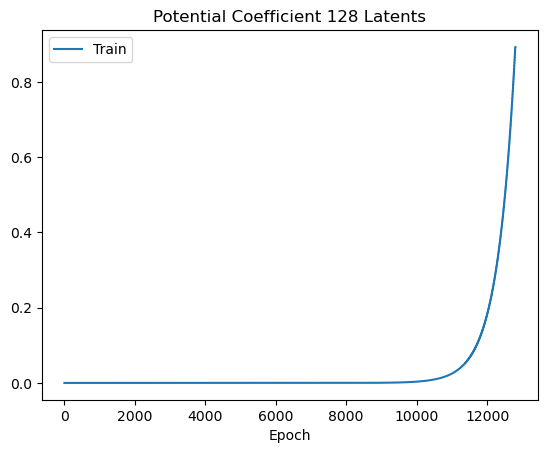

Num Epochs 12800
Last RMSD (nm): Train: 0.2288435697555542 Test 0.22906926274299622
Last PotDiff (% Deviation): Train: 2.523327811593746 Test 4.0897136155053415
256 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x7d1b74398b00>


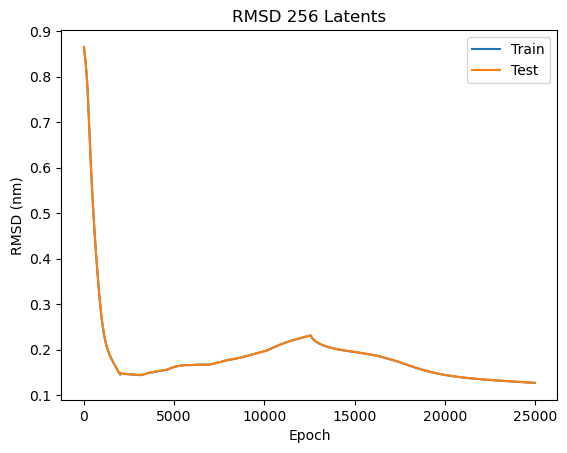

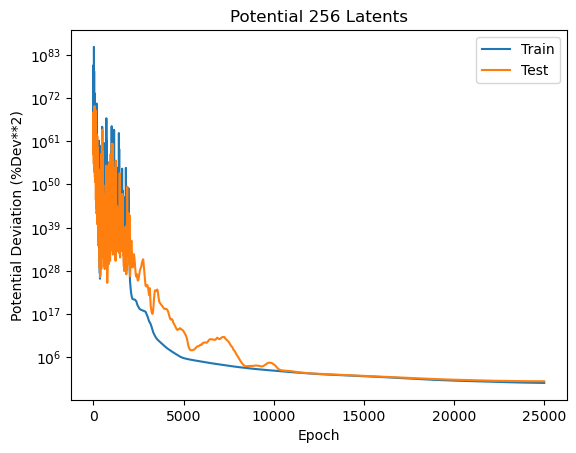

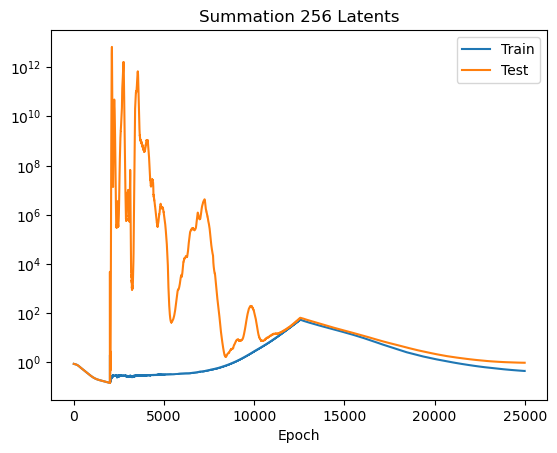

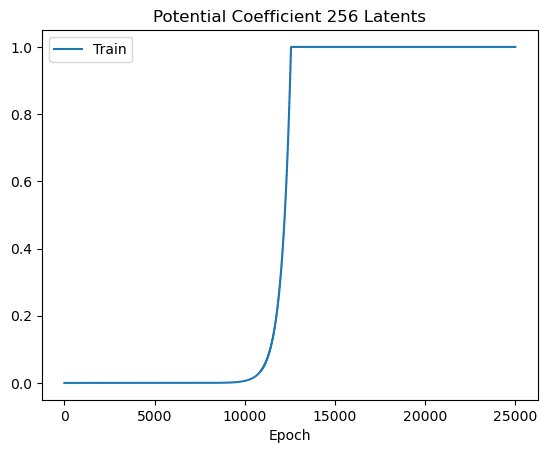

Num Epochs 25000
Last RMSD (nm): Train: 0.1270606815814972 Test 0.1272377073764801
Last PotDiff (% Deviation): Train: 0.31736431741136095 Test 0.8327554268625436
306 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x7d1b75e1e660>


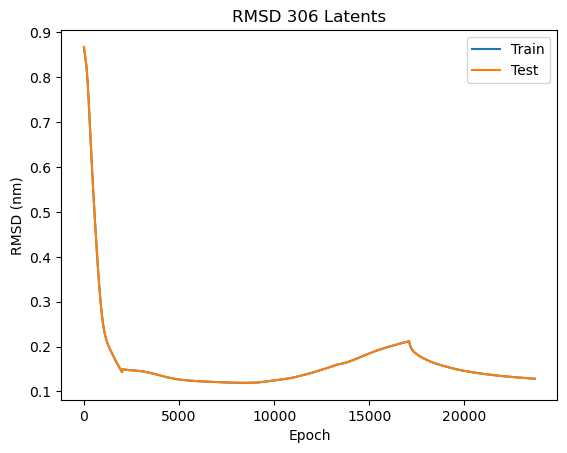

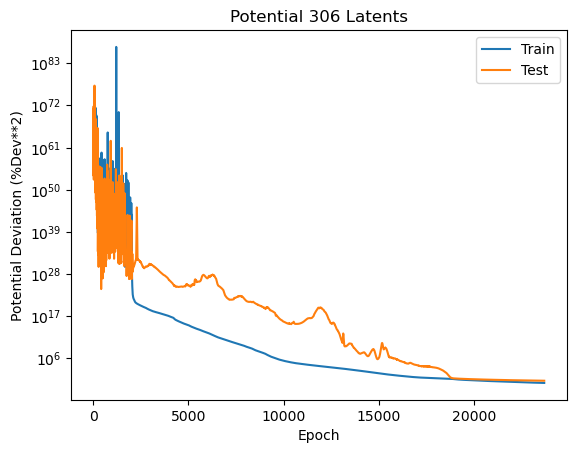

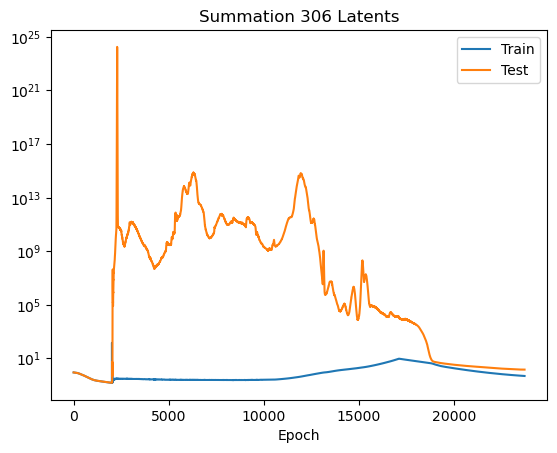

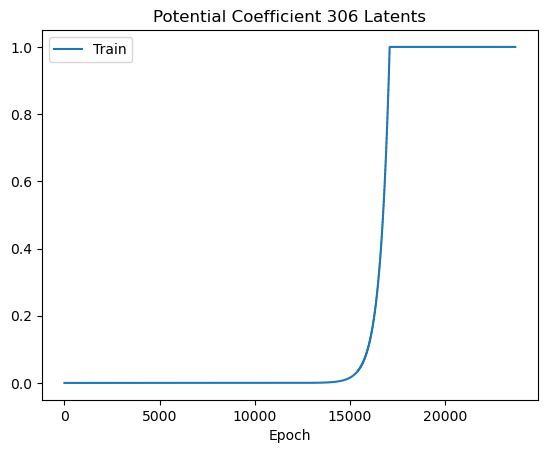

Num Epochs 23700
Last RMSD (nm): Train: 0.12828390300273895 Test 0.12829291820526123
Last PotDiff (% Deviation): Train: 0.34330365004173785 Test 1.2813769638250287


In [7]:
for key, exp in self.experiments.items():
    print(key, exp)
    exp.plot_results()

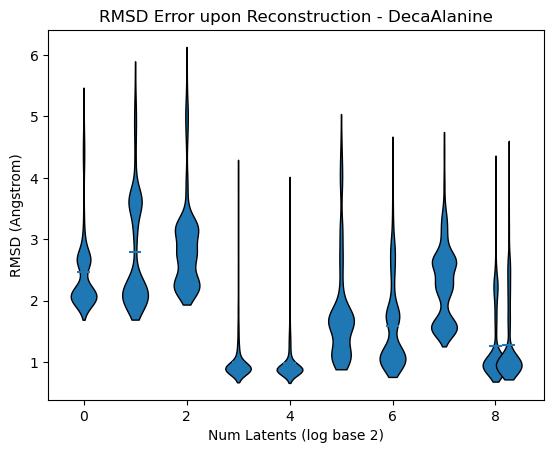

In [8]:
self.rmsd_violin_plot(rng_seed=98263, title='RMSD Error upon Reconstruction - DecaAlanine')

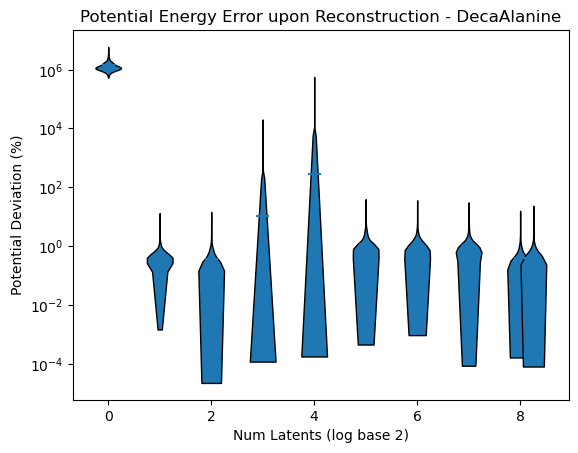

In [9]:
self.potential_violin_plot(rng_seed=98263, title='Potential Energy Error upon Reconstruction - DecaAlanine')

Outliers above 1000.0 kJ/mol for 1 Latents: 2000 (100.0 %)
Outliers above 1000.0 kJ/mol for 2 Latents: 31 (1.55 %)


/home/exouser/miniconda3/envs/jax_12/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Outliers above 1000.0 kJ/mol for 4 Latents: 74 (3.7 %)
Outliers above 1000.0 kJ/mol for 8 Latents: 41 (2.05 %)
Outliers above 1000.0 kJ/mol for 16 Latents: 42 (2.1 %)
Outliers above 1000.0 kJ/mol for 32 Latents: 412 (20.6 %)
Outliers above 1000.0 kJ/mol for 64 Latents: 374 (18.7 %)
Outliers above 1000.0 kJ/mol for 128 Latents: 356 (17.8 %)
Outliers above 1000.0 kJ/mol for 256 Latents: 83 (4.15 %)
Outliers above 1000.0 kJ/mol for 306 Latents: 90 (4.5 %)


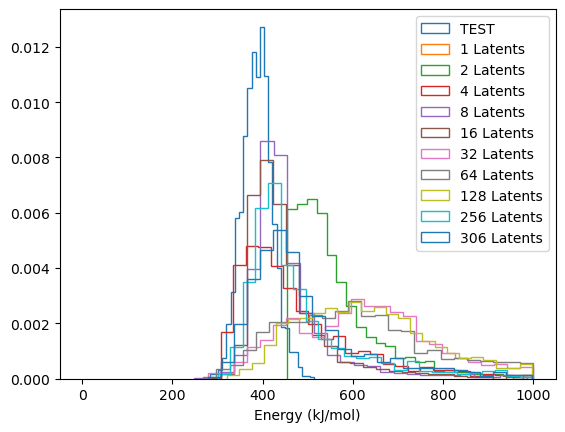

In [18]:
plt.clf()
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=25, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items()]
for key, exp in self.experiments.items():
    recon, _ = exp.operate(rng_seed)
    potentials = gas_fun(recon)
    num_outliers = potentials[potentials > threshold].shape[0]
    print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
    plt.hist(potentials[potentials < threshold], histtype='step', bins=25, density=True)
    
plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

Outliers above 1000.0 kJ/mol for 2 Latents: 31 (1.55 %)
Outliers above 1000.0 kJ/mol for 4 Latents: 74 (3.7 %)
Outliers above 1000.0 kJ/mol for 8 Latents: 41 (2.05 %)


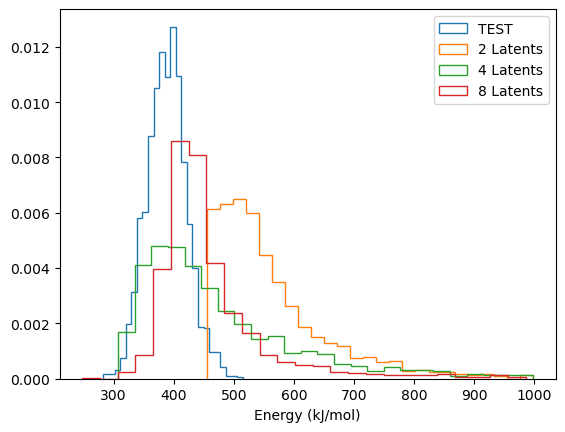

In [19]:
#Single Digits Latents
plt.clf()
n_latents = 10
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=25, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

Outliers above 1000.0 kJ/mol for 16 Latents: 42 (2.1 %)
Outliers above 1000.0 kJ/mol for 32 Latents: 412 (20.6 %)
Outliers above 1000.0 kJ/mol for 64 Latents: 374 (18.7 %)


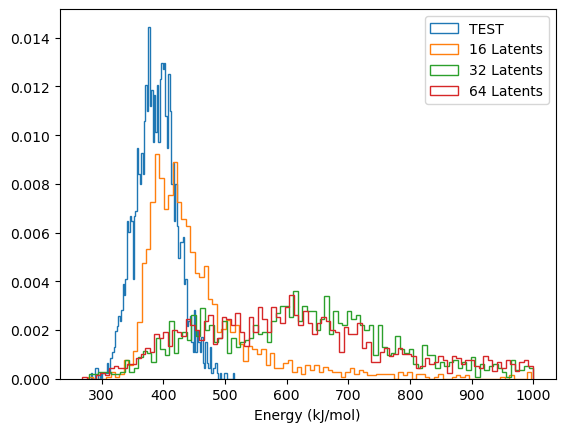

In [14]:
#Double Digits Latents
plt.clf()
n_latents = 100
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=100, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=100, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

Outliers above 1000.0 kJ/mol for 128 Latents: 356 (17.8 %)
Outliers above 1000.0 kJ/mol for 256 Latents: 83 (4.15 %)
Outliers above 1000.0 kJ/mol for 306 Latents: 90 (4.5 %)


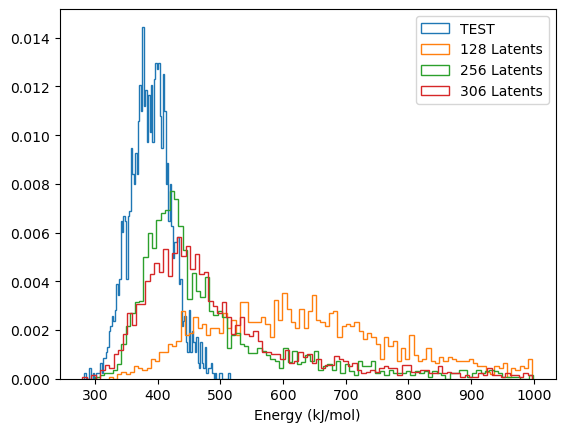

In [15]:
#Triple Digits Latents
plt.clf()
n_latents = 1000
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=100, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=100, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

Outliers above 1000.0 kJ/mol for 2 Latents: 24 (1.2 %)
Outliers above 1000.0 kJ/mol for 4 Latents: 74 (3.7 %)
Outliers above 1000.0 kJ/mol for 8 Latents: 1116 (55.8 %)


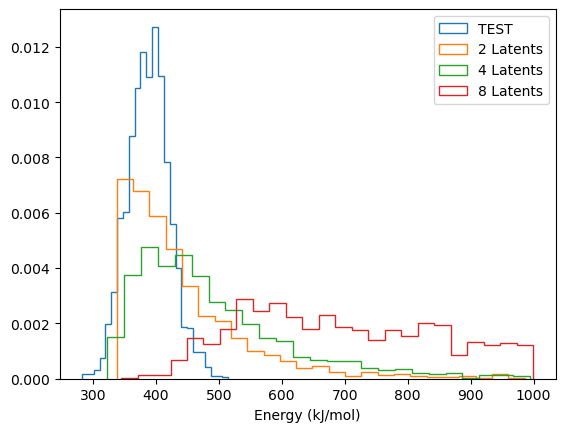

In [21]:
#Single Digits Latents
plt.clf()
n_latents = 10
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=25, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        _, samples = exp.gaussian_mm_fit(rng_seed, 5)
        recon = exp.decode(rng_seed, samples)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [7]:
A, B = self.super_traj_construct()

In [9]:
rmsd = jax.vmap(atom_rmsd)(A, B)

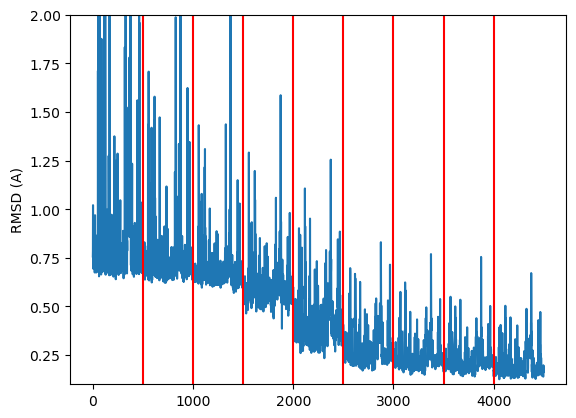

In [13]:
plt.clf()
_ = plt.plot(jnp.arange(rmsd.shape[0]), rmsd*10)
plt.vlines(jnp.array((500,1000,1500,2000,2500,3000,3500,4000)), jnp.array([0.025]*8), jnp.array([2.5]*8), colors='r')
plt.ylabel('RMSD (A)')
plt.ylim(0.1, 2)
plt.show()

In [12]:
def write_traj(fname, traj_xyz): #(n conf, n_atoms*3) OR (n conf, n_atoms, 3)
    if traj_xyz.shape[-1] != 3:
        traj_xyz = traj_xyz.reshape(traj_xyz.shape[0], -1, 3)
    
    with md.formats.DCDTrajectoryFile(fname, 'w') as f:
        f.write(traj_xyz*10) #*10 because mdtraj loads data in nm but writes it as angstrom (charmdcd standard is angstrom)

In [9]:
write_traj('Test_Data_Super.dcd', A)
write_traj('Decoded_Data_Super.dcd', B)

In [1]:
#Write a PDB for visualization with OpenMM

In [25]:
from openmm import *
from openmm.app import *
from openmm.unit import *

In [21]:
prmtop = AmberPrmtopFile('Simulation/1crn_H.prmtop')

In [15]:
positions = A[0, :].reshape(-1, 3)

In [26]:
with open('1crn_H.pdb', 'w') as f:
    PDBFile.writeModel(prmtop.topology, positions*10, file=f)